In [10]:
from torch.quantization import quantize_dynamic
from sentence_transformers import SentenceTransformer, util, InputExample, losses
import pandas as pd

In [11]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.cluster import MiniBatchKMeans
import gensim
from gensim import corpora
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm import tqdm
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /Users/lea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
# Load SBERT model
model = SentenceTransformer('paraphrase-MiniLM-L3-v2')

In [13]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/lea/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
# Function to read and preprocess text data
def read_and_preprocess(file_path, column_index=0, delimiter='\t'):
    
    df = pd.read_csv(file_path, delimiter=delimiter, header=None, on_bad_lines='skip')
    text = ' '.join(df[column_index].astype(str).tolist())
    text = text.replace('\n', ' ')
    sentences = nltk.sent_tokenize(text)
    
    return [sentence.strip() for sentence in sentences if sentence.strip()]

In [15]:
def read_and_preprocess_per_movie(file_path, column_index=0, delimiter='\n'):
    with open(file_path, 'r', encoding='utf-8') as file:
        movies_summary = [line.strip() for line in file.readlines() if line.strip()] 
    return movies_summary

In [29]:
# Load datasets
movies_sentences_1900 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1900.txt')
movies_sentences_1910 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1910.txt')
movies_sentences_1920 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1920.txt')
movies_sentences_1930 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1930.txt')
movies_sentences_1940 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1940.txt')
movies_sentences_1950 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1950.txt')
movies_sentences_1960 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1960.txt')
movies_sentences_1970 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1970.txt')
movies_sentences_1980 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1980.txt')
movies_sentences_1990 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_1990.txt')
movies_sentences_2000 = read_and_preprocess('src/data/Summaries_decades/summaries_decade_2000.txt')

In [30]:
embeddings_1900 = model.encode(movies_sentences_1900, batch_size=32, convert_to_tensor=True)
embeddings_1910 = model.encode(movies_sentences_1910, batch_size=32, convert_to_tensor=True)
embeddings_1920 = model.encode(movies_sentences_1920, batch_size=32, convert_to_tensor=True)
embeddings_1930 = model.encode(movies_sentences_1930, batch_size=32, convert_to_tensor=True)
embeddings_1940 = model.encode(movies_sentences_1940, batch_size=32, convert_to_tensor=True)
embeddings_1950 = model.encode(movies_sentences_1950, batch_size=32, convert_to_tensor=True)
embeddings_1960 = model.encode(movies_sentences_1960, batch_size=32, convert_to_tensor=True)
embeddings_1970 = model.encode(movies_sentences_1970, batch_size=32, convert_to_tensor=True)
embeddings_1980 = model.encode(movies_sentences_1980, batch_size=32, convert_to_tensor=True)
embeddings_1990 = model.encode(movies_sentences_1990, batch_size=32, convert_to_tensor=True)
embeddings_2000 = model.encode(movies_sentences_2000, batch_size=32, convert_to_tensor=True)

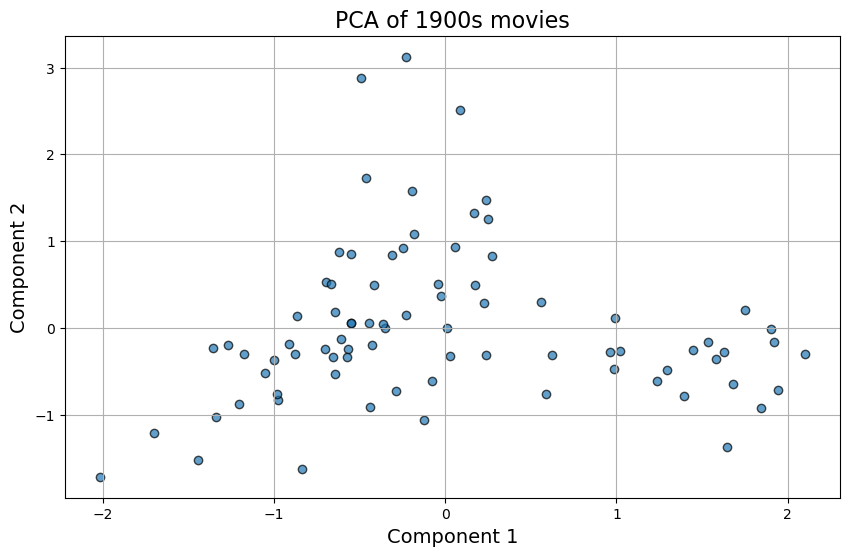

In [25]:
pca = PCA(n_components=2)
pca_1900 = pca.fit_transform(embeddings_1900)

plt.figure(figsize=(10, 6))
plt.scatter(pca_1900[:, 0], pca_1900[:, 1], alpha=0.7, edgecolors='k')
plt.title("PCA of 1900s movies", fontsize=16)
plt.xlabel("Component 1", fontsize=14)
plt.ylabel("Component 2", fontsize=14)
plt.grid(True)
plt.show()


Cluster labels for each point: [0 0 2 0 2 2 0 0 0 0 0 0 2 2 2 0 2 2 2 2 0 2 2 0 2 0 0 2 2 0 0 0 0 0 0 0 2
 0 2 0 2 2 2 0 2 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3 3 3 3 2 3 2 3 3 3
 3 2 0 2 2 1 3]


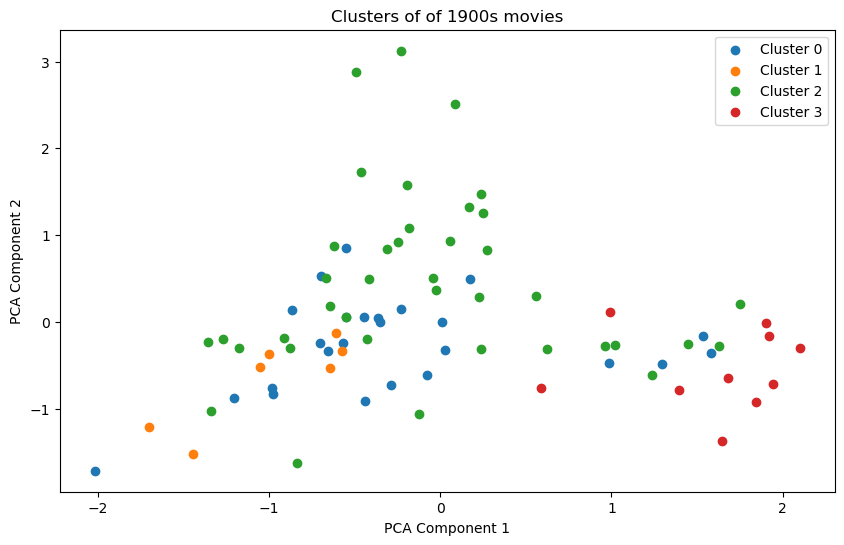

In [28]:
n = 4

kmeans = KMeans(n_clusters=n, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_1900.cpu().numpy())

print(f"Cluster labels for each point: {cluster_labels}")

pca = PCA(n_components=2)
pca_1900 = pca.fit_transform(embeddings_1900)

plt.figure(figsize=(10, 6))
for cluster in range(n):
    cluster_points = pca_1900[cluster_labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}')
    
#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Clusters of of 1900s movies')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In [31]:
pca_1900 = pca.fit_transform(embeddings_1900)
pca_1910 = pca.fit_transform(embeddings_1910)
pca_1920 = pca.fit_transform(embeddings_1920)
pca_1930 = pca.fit_transform(embeddings_1930)
pca_1940 = pca.fit_transform(embeddings_1940)
pca_1950 = pca.fit_transform(embeddings_1950)
pca_1960 = pca.fit_transform(embeddings_1960)
pca_1970 = pca.fit_transform(embeddings_1970)
pca_1980 = pca.fit_transform(embeddings_1980)
pca_1990 = pca.fit_transform(embeddings_1990)
pca_2000 = pca.fit_transform(embeddings_2000)

/Users/lea/opt/anaconda3/envs/ada2/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


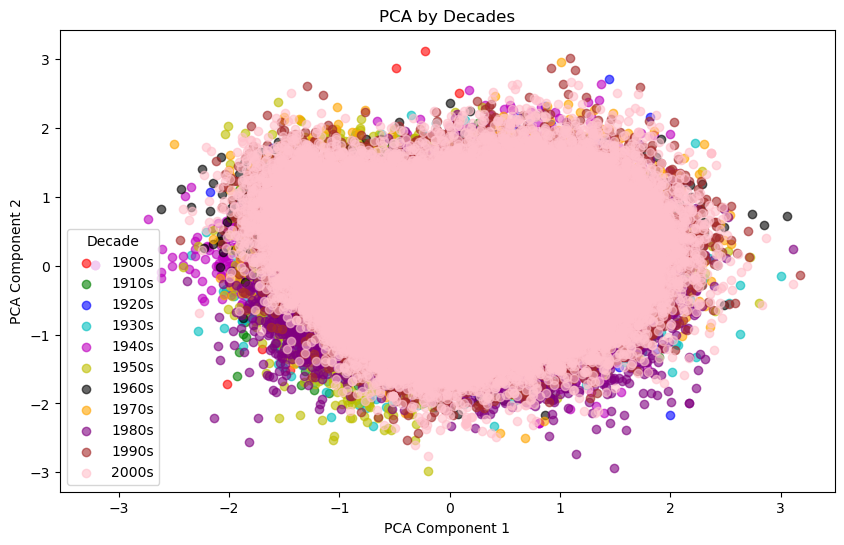

In [32]:

pca_results = {'1900s': pca_1900,'1910s': pca_1910,'1920s': pca_1920,'1930s': pca_1930,'1940s': pca_1940,'1950s': pca_1950,'1960s': pca_1960,'1970s': pca_1970,'1980s': pca_1980,'1990s': pca_1990,'2000s': pca_2000
}

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink']

plt.figure(figsize=(10, 6))

for i, (decade, pca_data) in enumerate(pca_results.items()):
    plt.scatter(pca_data[:, 0], pca_data[:, 1], label=decade, color=colors[i], alpha=0.6)

plt.title('PCA by Decades')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Decade')

plt.show()


In [ ]:
n = 3

kmeans = KMeans(n_clusters=n, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_1900.cpu().numpy())

clustered_movies = {i: [] for i in range(max(cluster_labels) + 1)}
for idx, cluster_id in enumerate(cluster_labels):
    clustered_movies[cluster_id].append(movies_sentences_1900[idx])

cluster_sentences=''
for idx,cluster in clustered_movies.items():    
    for sentence in cluster:
        cluster_sentences+=sentence
    cluster_sentences+='\n'

  # Save the movie clusters in a text file
with open (f'src/data/clusters/movies_clusters_{decade}', "w") as file :
    file.write(cluster_sentences)

print(f"Cluster labels for each point: {cluster_labels}")

pca = PCA(n_components=2)
pca_1910 = pca.fit_transform(embeddings_1910)

plt.figure(figsize=(10, 6))
for cluster in range(n):
    cluster_points = pca_1910[cluster_labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}')
    
#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Clusters of of 1910s movies')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In [48]:
# Calculating the optimal number of clusters
def best_n_clusters(embeddings):
    best_clust_nums=np.zeros(20)
    num_clusters = np.arange(1,20,1)+1
    sil_scores= np.zeros(len(num_clusters))
    for i in tqdm(np.arange(len(num_clusters))):
      cluster_model = MiniBatchKMeans(n_clusters=num_clusters[i])
      cluster_labels = cluster_model.fit_predict(embeddings.cpu().numpy())
      sil_score = silhouette_score(embeddings.cpu().numpy(), cluster_labels)
      sil_scores[i]= sil_score
    best_clust_num=num_clusters[np.argmax(sil_scores)] # number of clusters with the best silhouette score
    print(best_clust_num)
    return best_clust_num

In [49]:
n_1910 = best_n_clusters(embeddings_1910)

100%|███████████████████████████████████████████| 19/19 [00:03<00:00,  5.81it/s]

2


Cluster labels for each point: [0 0 0 ... 0 0 0]


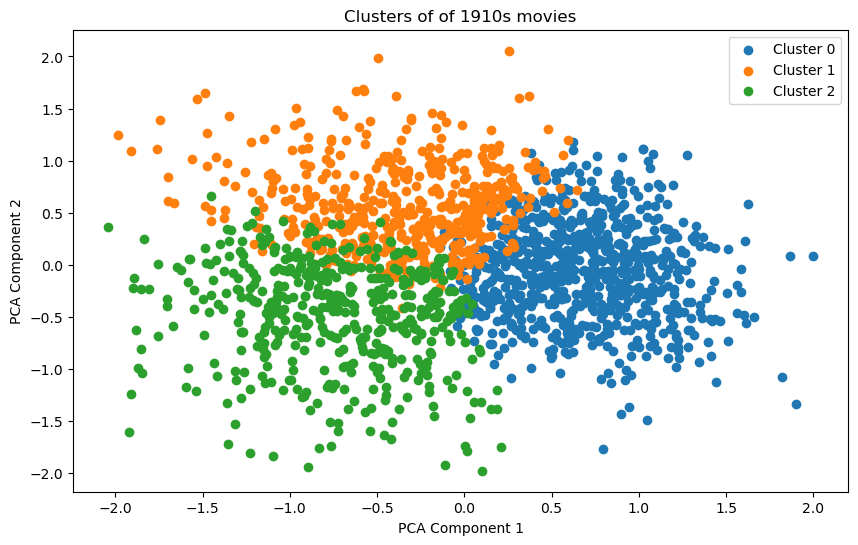

In [40]:
#n = 3

kmeans = KMeans(n_clusters=n, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_1910.cpu().numpy())

clustered_movies = {i: [] for i in range(max(cluster_labels) + 1)}
for idx, cluster_id in enumerate(cluster_labels):
    clustered_movies[cluster_id].append(movies_sentences_1910[idx])

cluster_sentences=''
for idx,cluster in clustered_movies.items():    
    for sentence in cluster:
        cluster_sentences+=sentence
    cluster_sentences+='\n'

  # Save the movie clusters in a text file
with open (f'src/data/clusters/movies_clusters_{decade}', "w") as file :
    file.write(cluster_sentences)

print(f"Cluster labels for each point: {cluster_labels}")

pca = PCA(n_components=2)
pca_1910 = pca.fit_transform(embeddings_1910)

plt.figure(figsize=(10, 6))
for cluster in range(n):
    cluster_points = pca_1910[cluster_labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}')
    
plt.title('Clusters of of 1910s movies')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In [71]:
def cluster_plot(embeddings, movies_sentences, decade, n_clusters=3): #cluster_names
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings.cpu().numpy())

    clustered_movies = {i: [] for i in range(n_clusters)}
    for idx, cluster_id in enumerate(cluster_labels):
        clustered_movies[cluster_id].append(movies_sentences[idx])

    cluster_sentences = ''
    for cluster_id, cluster in clustered_movies.items():
        for sentence in cluster:
            cluster_sentences += sentence
        cluster_sentences += '\n'
    
    with open(f'src/data/clusters/movies_clusters/clusters_per_movie_{decade}.txt', "w") as file:
        file.write(cluster_sentences)

    print(f"Cluster labels for each point: {cluster_labels}")

    pca = PCA(n_components=2)
    pca_embeddings = pca.fit_transform(embeddings.cpu().numpy())
    pca_df = pd.DataFrame(pca_embeddings, columns=['PCA Component 1', 'PCA Component 2'])
    #pca_df.to_csv(f'src/data/clusters/pcas/pca_{decade}.csv', index=False)
    

    plt.figure(figsize=(10, 6))
    for cluster in range(n_clusters):
        cluster_points = pca_embeddings[cluster_labels == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}' ) #label=f'Cluster {cluster_names[cluster]}'

    plt.title(f'Clusters of {decade} Movies')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.show()


Cluster labels for each point: [0 0 2 0 2 2 0 0 0 0 0 0 2 2 2 0 2 2 2 2 0 2 2 0 2 0 0 2 2 0 0 0 0 0 2 0 2
 0 0 0 0 0 0 0 2 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 0 0 2 2 0 2 2 0 0 0
 0 2 0 2 0 1 0]


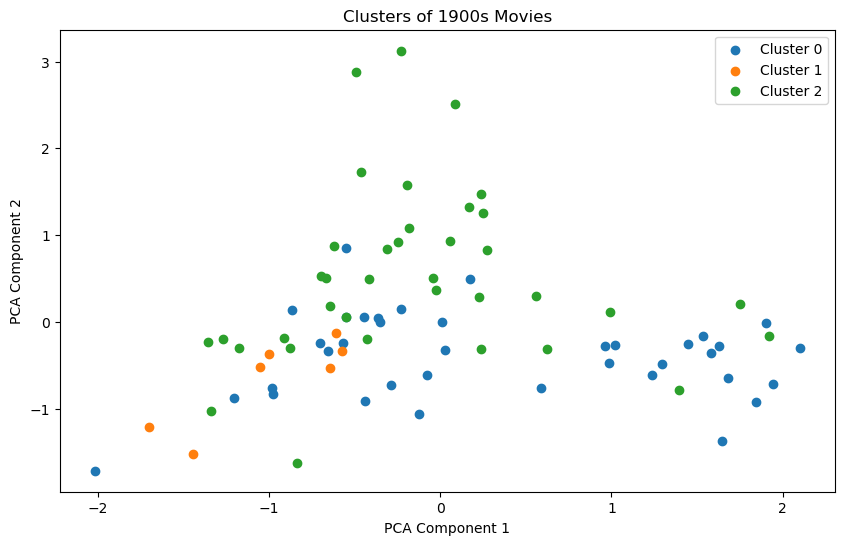

In [52]:
cluster_plot(embeddings_1900, movies_sentences_1900, '1900s', n_clusters=3)

  0%|                                                    | 0/11 [00:00<?, ?it/s]

Cluster labels for each point: [0 0 2 0 2 2 0 0 0 0 0 0 2 2 2 0 2 2 2 2 0 2 2 0 2 0 0 2 2 0 0 0 0 0 2 0 2
 0 0 0 0 0 0 0 2 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 0 0 2 2 0 2 2 0 0 0
 0 2 0 2 0 1 0]


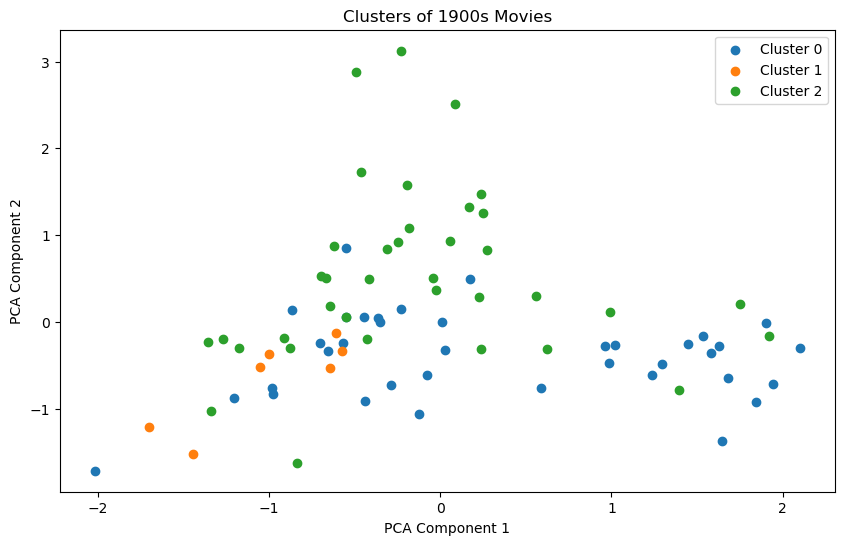

  9%|████                                        | 1/11 [00:00<00:02,  3.80it/s]

Cluster labels for each point: [0 0 0 ... 0 0 0]


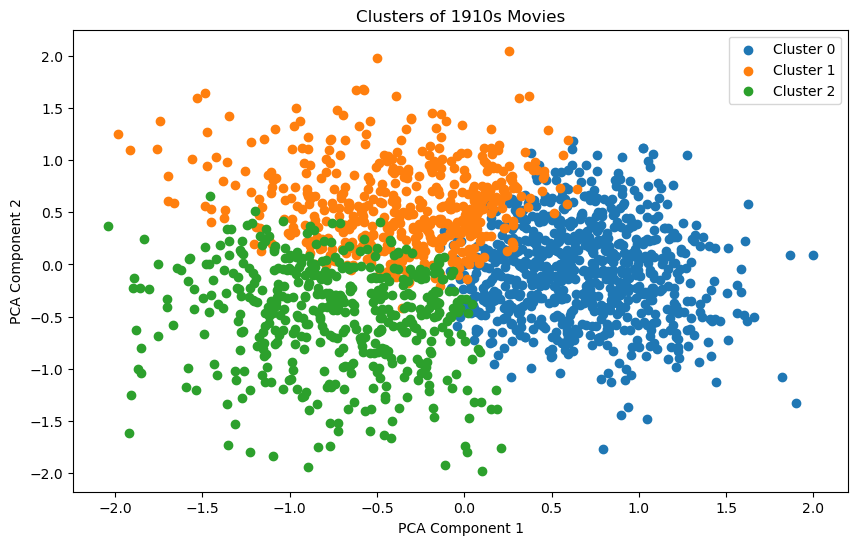

 18%|████████                                    | 2/11 [00:00<00:03,  2.99it/s]

Cluster labels for each point: [1 2 0 ... 1 2 2]


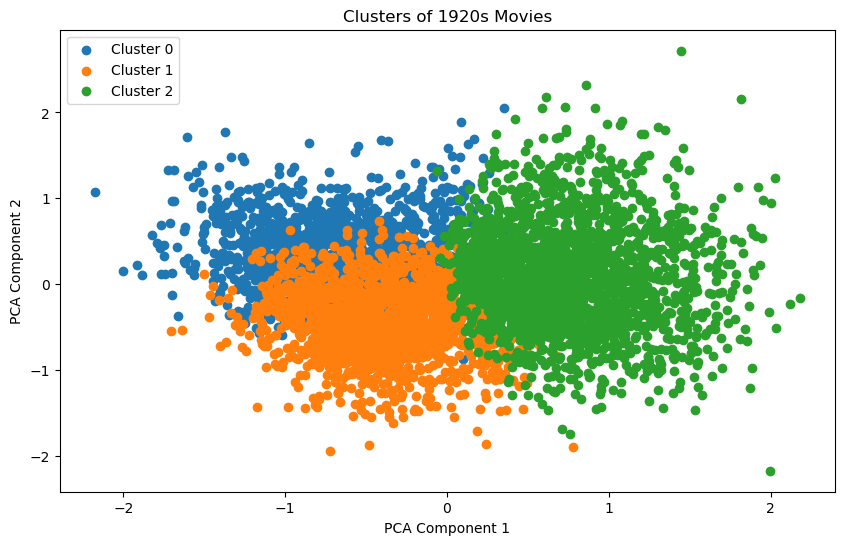

 27%|████████████                                | 3/11 [00:01<00:03,  2.42it/s]

Cluster labels for each point: [2 1 0 ... 2 2 2]


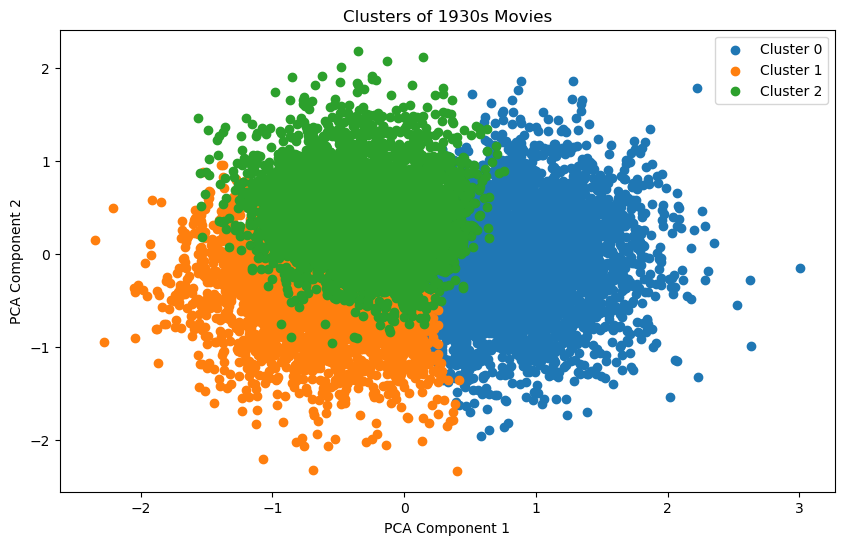

 36%|████████████████                            | 4/11 [00:02<00:04,  1.70it/s]

Cluster labels for each point: [2 0 0 ... 1 2 0]


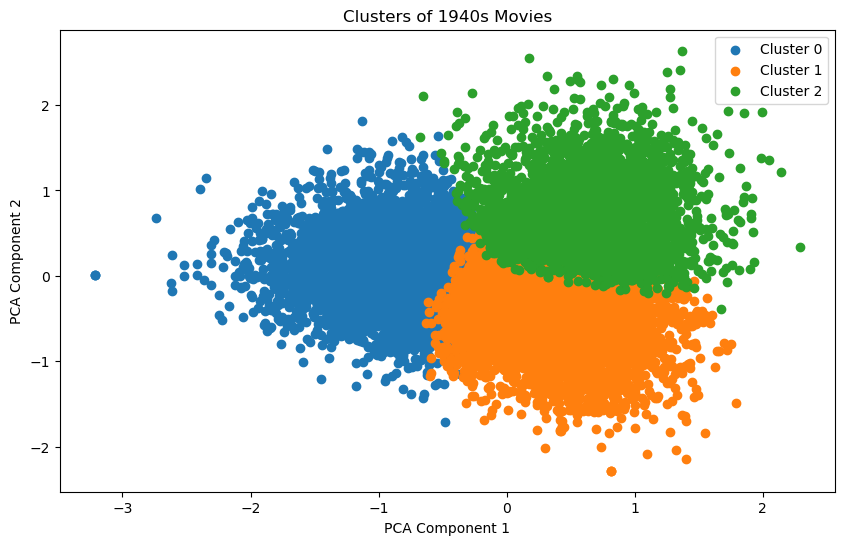

 45%|████████████████████                        | 5/11 [00:02<00:03,  1.59it/s]

Cluster labels for each point: [2 2 2 ... 1 2 2]


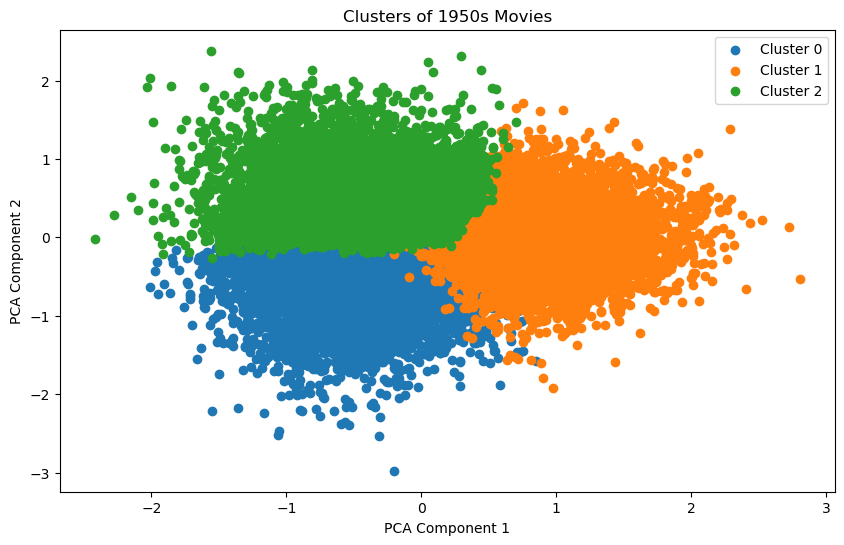

 55%|████████████████████████                    | 6/11 [00:03<00:04,  1.20it/s]

Cluster labels for each point: [1 1 0 ... 0 1 1]


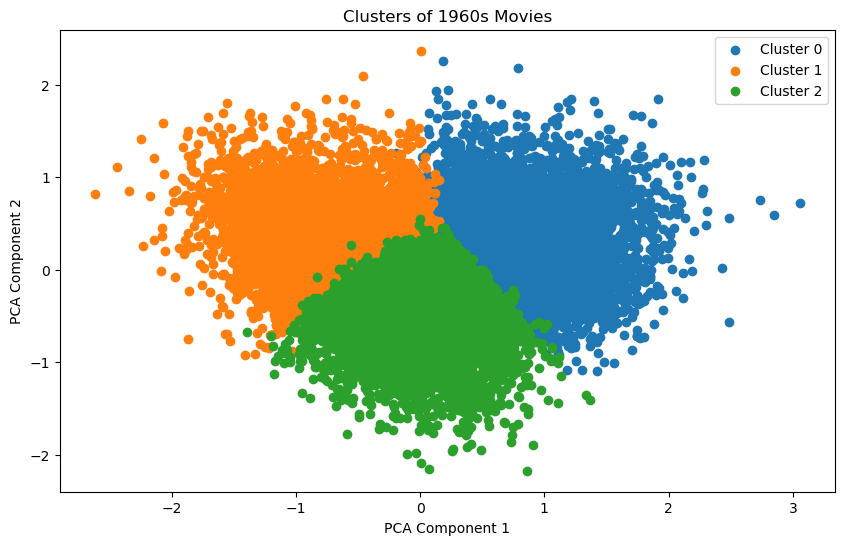

 64%|████████████████████████████                | 7/11 [00:04<00:03,  1.24it/s]

Cluster labels for each point: [0 2 1 ... 0 0 1]


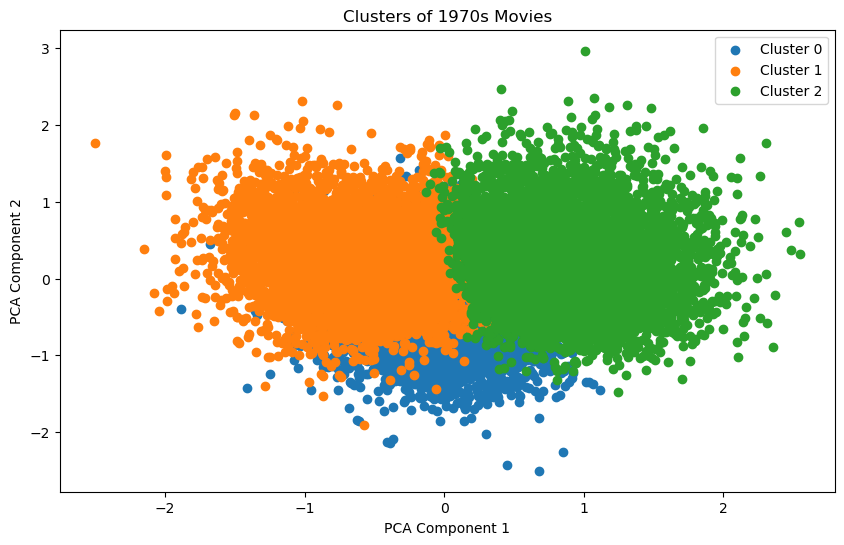

 73%|████████████████████████████████            | 8/11 [00:05<00:02,  1.22it/s]

Cluster labels for each point: [2 0 0 ... 1 0 1]


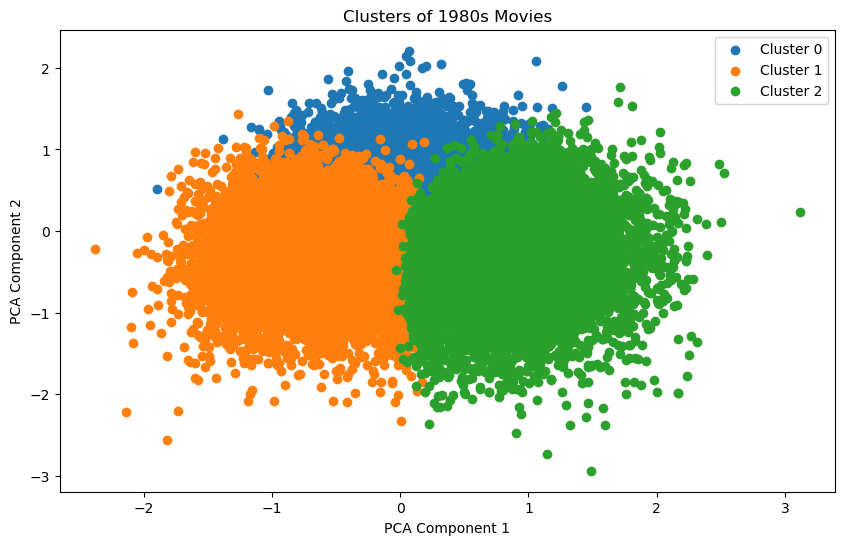

 82%|████████████████████████████████████        | 9/11 [00:06<00:01,  1.04it/s]

Cluster labels for each point: [2 2 2 ... 2 1 1]


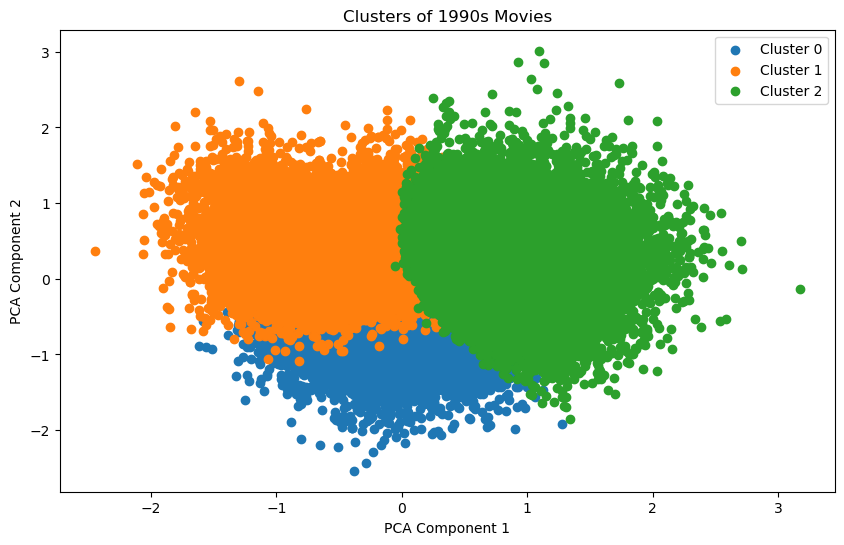

 91%|███████████████████████████████████████    | 10/11 [00:09<00:01,  1.34s/it]

Cluster labels for each point: [0 2 0 ... 1 1 1]


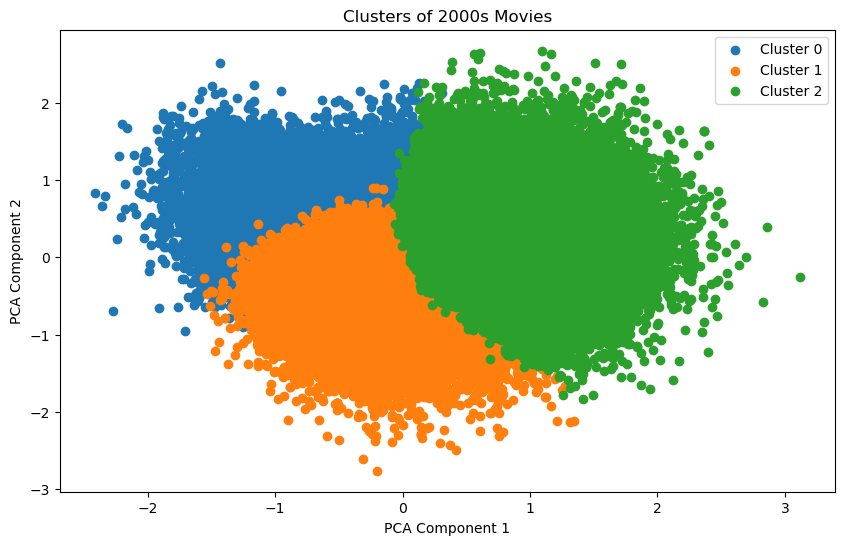

100%|███████████████████████████████████████████| 11/11 [00:14<00:00,  1.28s/it]


In [53]:
mov_dec = [
    (embeddings_1900, movies_sentences_1900, '1900s'),
    (embeddings_1910, movies_sentences_1910, '1910s'),
    (embeddings_1920, movies_sentences_1920, '1920s'),
    (embeddings_1930, movies_sentences_1930, '1930s'),
    (embeddings_1940, movies_sentences_1940, '1940s'),
    (embeddings_1950, movies_sentences_1950, '1950s'),
    (embeddings_1960, movies_sentences_1960, '1960s'),
    (embeddings_1970, movies_sentences_1970, '1970s'),
    (embeddings_1980, movies_sentences_1980, '1980s'),
    (embeddings_1990, movies_sentences_1990, '1990s'),
    (embeddings_2000, movies_sentences_2000, '2000s')
]

for embeddings, sentences, decade in tqdm(mov_dec):
    cluster_plot(embeddings, sentences, decade, n_clusters=3)

In [16]:
movies_1900s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1900.txt')
movies_1910s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1910.txt')
movies_1920s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1920.txt')
movies_1930s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1930.txt')
movies_1940s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1940.txt')
movies_1950s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1950.txt')
movies_1960s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1960.txt')
movies_1970s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1970.txt')
movies_1980s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1980.txt')
movies_1990s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_1990.txt')
movies_2000s = read_and_preprocess_per_movie('src/data/Summaries_decades/summaries_decade_2000.txt')

In [17]:
movies_decades = [
    movies_1900s,
    movies_1910s,
    movies_1920s,
    movies_1930s,
    movies_1940s,
    movies_1950s,
    movies_1960s,
    movies_1970s,
    movies_1980s,
    movies_1990s,
    movies_2000s
]

embed_mov = []

for decade in tqdm(movies_decades):
    emb = model.encode(decade, batch_size=32, convert_to_tensor=True)
    embed_mov.append(emb)

100%|███████████████████████████████████████████| 11/11 [04:55<00:00, 26.83s/it]



0it [00:00, ?it/s]

Cluster labels for each point: [2 1 1 0 0 0 1 1 1 1 0 0 1]


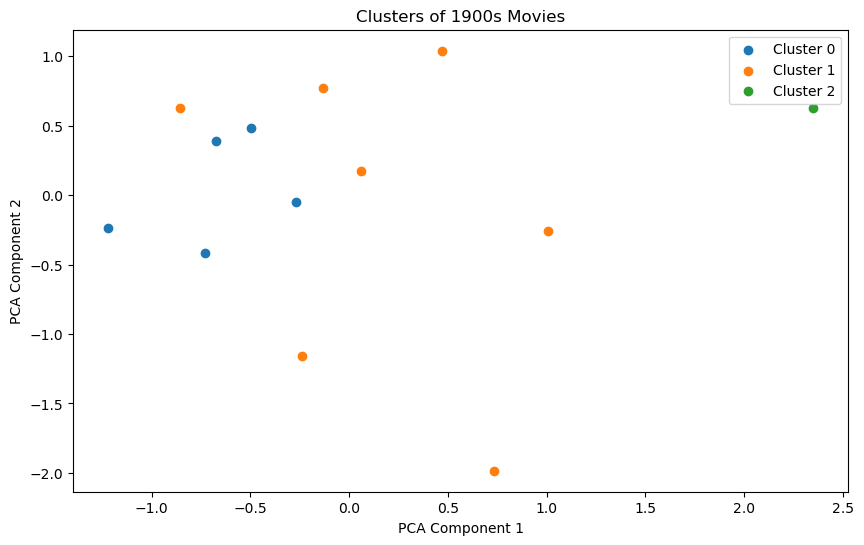


1it [00:00,  2.42it/s]

Cluster labels for each point: [0 0 0 0 0 0 0 2 0 0 1 2 0 0 1 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1 0 2 1 1
 0 0 1 1 1 2 0 1 0 0 1 1 0 2 0 0 1 0 2 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0
 1 0 1 2 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 2 1
 1 0 1 0 0 0 0 0 0 2 0 2 1 0 0 1 1 0 0 0 0 0 1 0 2 0 0 0 1 0 1 1 0 0 0 1 2
 0 1 1 0 0 0 0 0 1 0 0 0 0 0 2 1 1 0 1 0 1 0 0 0 0 1 1 0 1 1 1 0 0 1 0 1 0
 1 1 0 0 1 0 0 0 0 2 1 0 0 0 0 1 1 2 0 0 0 2 1 1 1 2]


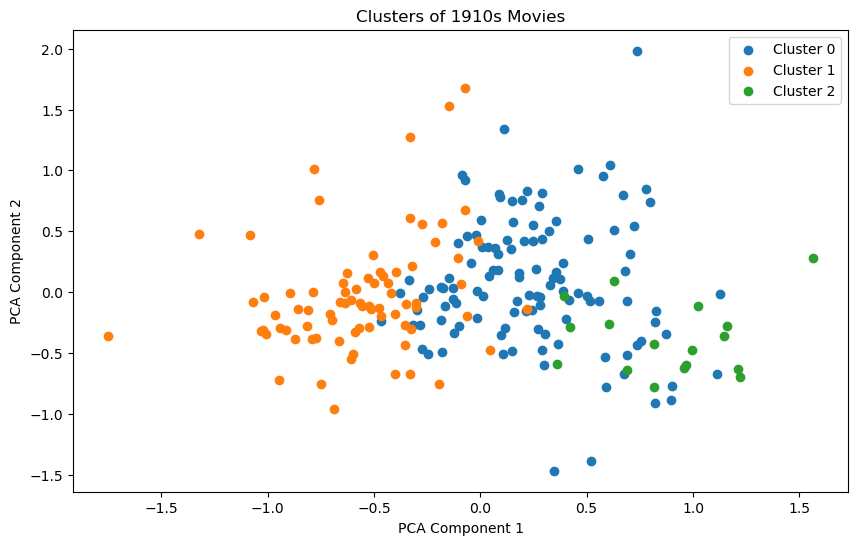


2it [00:00,  2.83it/s]

Cluster labels for each point: [1 1 1 1 1 2 2 2 1 1 2 1 2 2 1 1 1 2 1 2 1 1 2 2 2 1 1 1 2 2 2 1 1 1 1 1 1
 1 1 2 1 1 1 2 1 1 2 2 1 1 2 1 1 2 1 1 2 1 2 1 1 1 1 2 2 2 1 2 1 2 2 1 1 1
 1 1 2 1 1 1 1 1 2 1 2 1 1 1 2 1 1 1 2 2 2 1 2 2 1 1 1 1 1 2 1 2 1 1 1 2 1
 1 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 2 2 2 1 1 1 2 1 1 2 1 1 1 1 2 2 1 1 2 1 1
 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 1 1 1 2 2 0 2 2 2 1 1 1 1 2 2 2 1 1 1 1
 1 1 1 1 1 2 1 1 2 2 1 2 1 1 2 2 2 2 2 2 1 2 1 2 1 1 1 1 2 1 1 1 1 2 1 2 2
 1 1 2 2 1 1 1 2 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1 2 1 2 1 1
 1 1 2 1 2 1 1 1 1 1 1 1 2 1 1 1 2 1 2 2 1 1 1 1 1 2 2 1 1 2 1 1 2 1 1 2 1
 1 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 2 1 2 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1
 2 1 1 1 1 1 1 1 2 1 2 1 1 2 1 1 1 1 2 1 1 1 2 1 1 2 1 1 2 1 1 1 2 1 1 1 2
 1 1 2 1 1 1 2 1 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1 2 2 2 2 2 1 2 1 1 1 1 1 1 2
 2 1 2 1 2 2 1 1 2 1 1 1 2 2 1 1 2 2 1 2 2 1 1 2 1 1 1 2 2 1 1 2 1 1 1 2 1
 1 1 1 1 1 1 1 2 1 1]


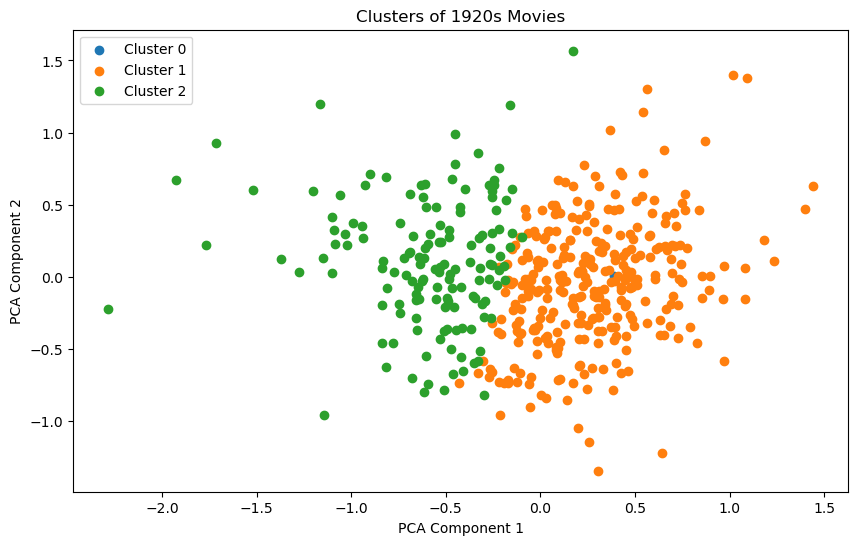


3it [00:01,  2.83it/s]

Cluster labels for each point: [2 1 2 ... 2 1 0]


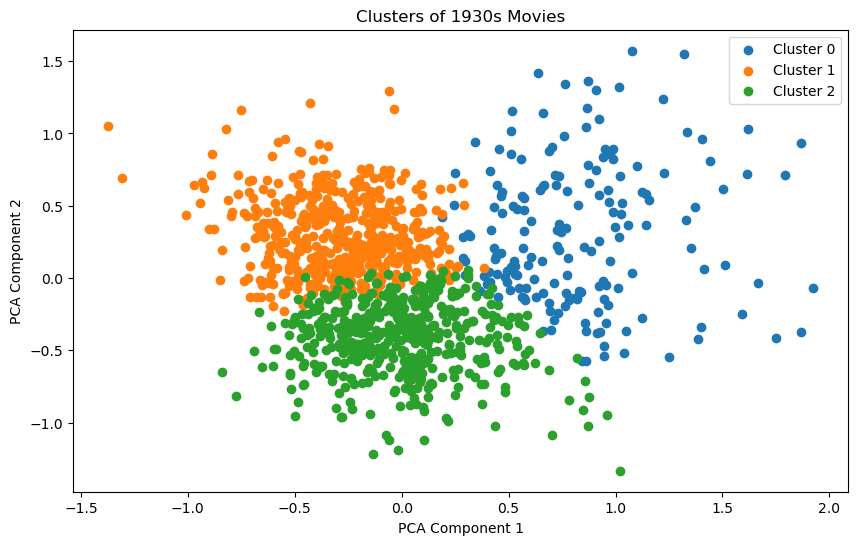


4it [00:01,  2.85it/s]

Cluster labels for each point: [2 2 2 ... 2 0 0]


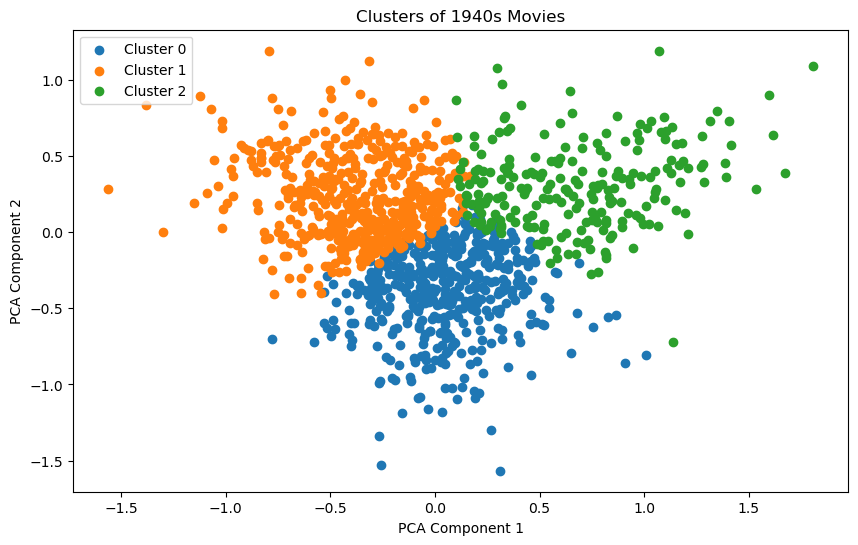


5it [00:01,  2.80it/s]

Cluster labels for each point: [0 0 1 ... 1 1 1]


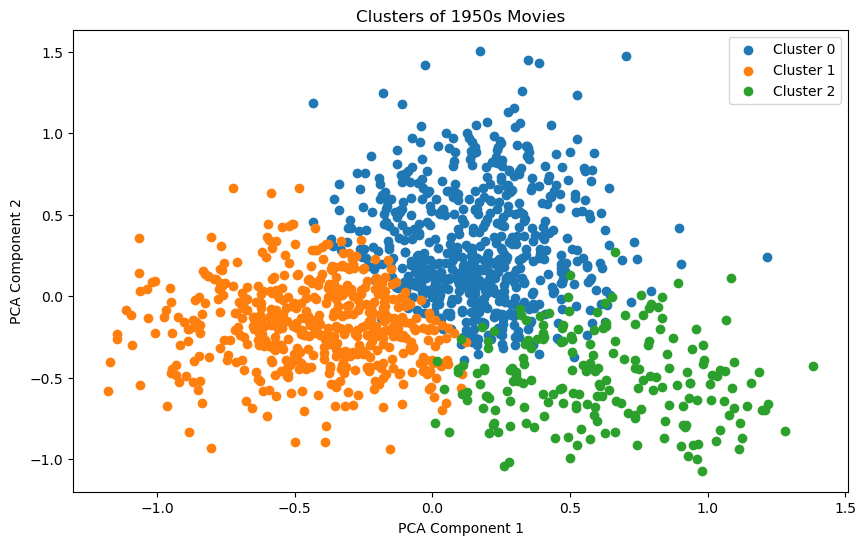


6it [00:02,  2.82it/s]

Cluster labels for each point: [0 2 1 ... 1 1 2]


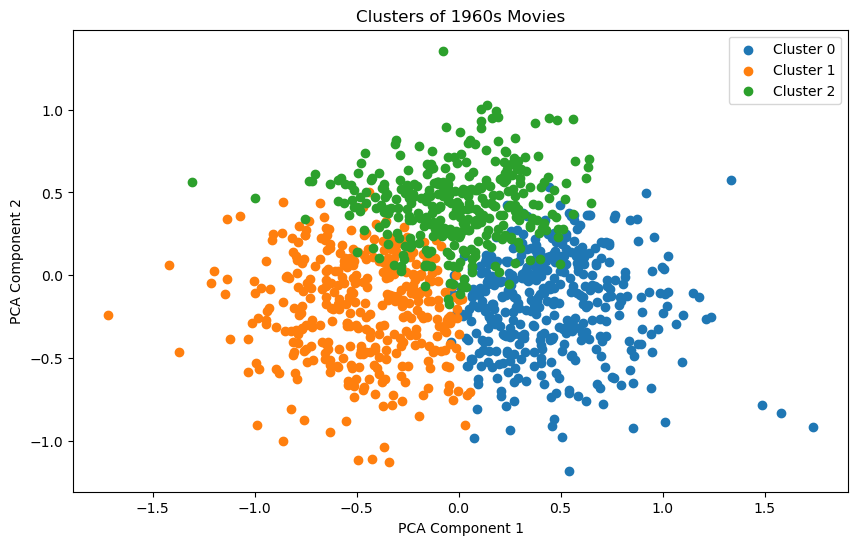


7it [00:02,  2.83it/s]

Cluster labels for each point: [1 2 1 ... 0 2 0]


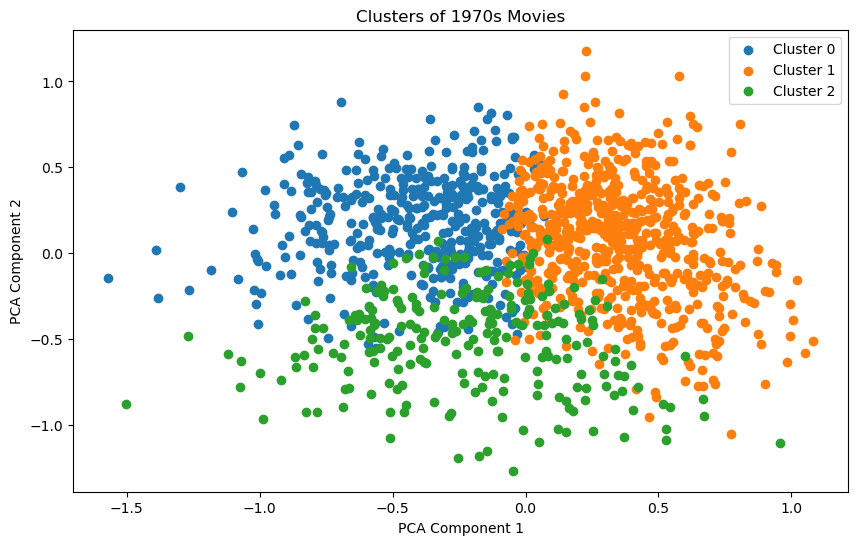


8it [00:02,  2.82it/s]

Cluster labels for each point: [1 0 0 ... 0 1 0]


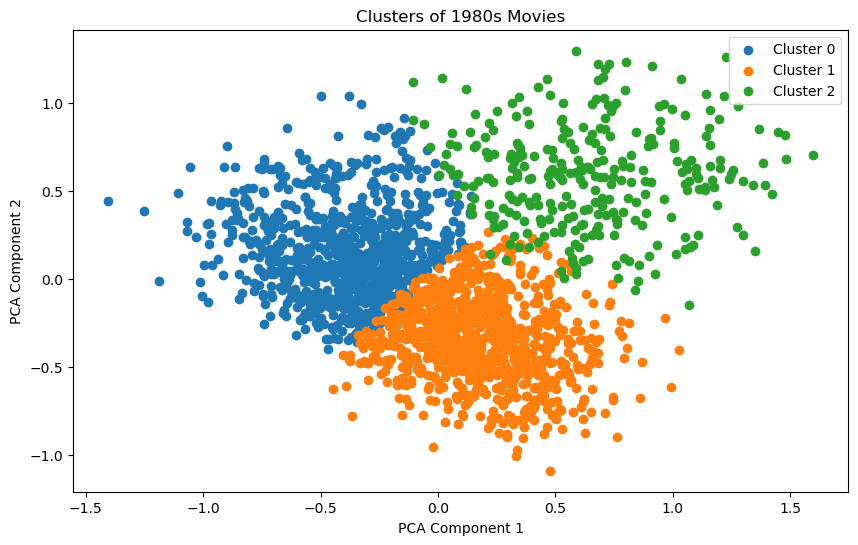


9it [00:03,  2.58it/s]

Cluster labels for each point: [0 0 1 ... 1 1 2]


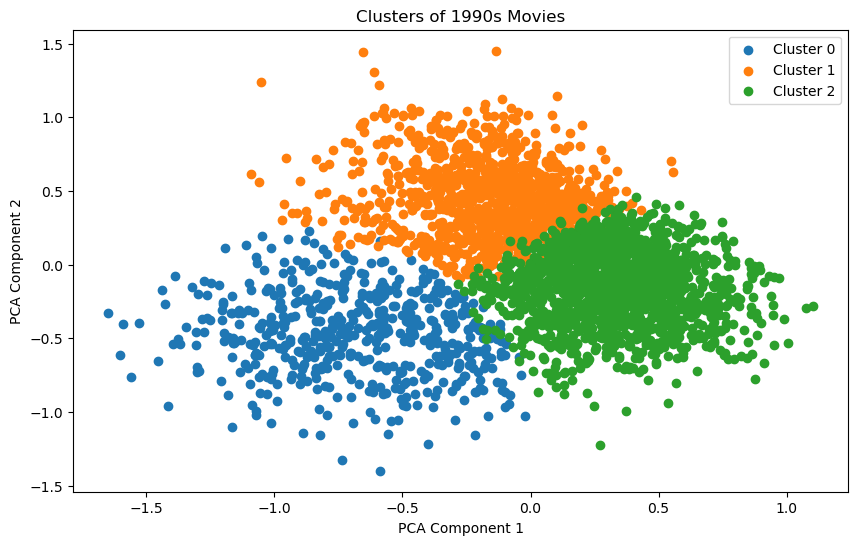


10it [00:04,  2.05it/s]

Cluster labels for each point: [1 0 0 ... 0 1 2]


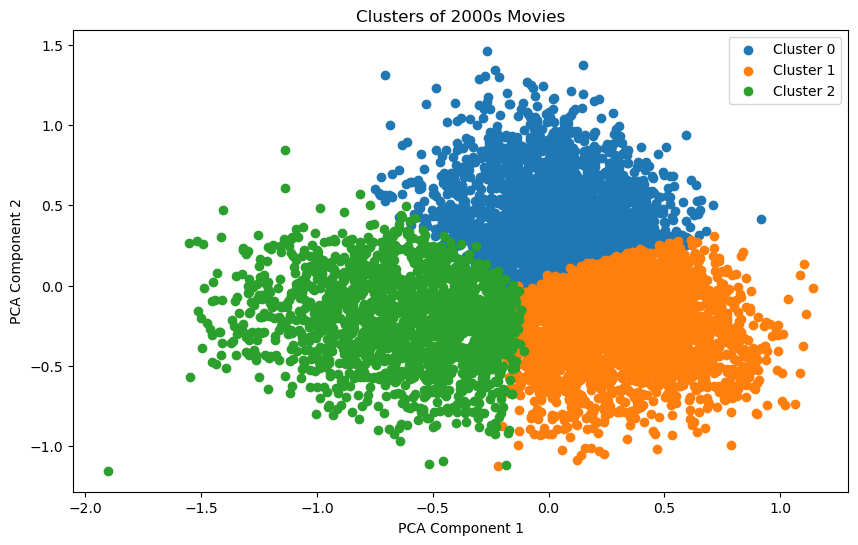


11it [00:04,  2.25it/s]


In [72]:
all_mov_decades = ['1900s', '1910s', '1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s']


for embeddings, movie, decade in tqdm(zip(embed_mov, movies_decades, all_mov_decades)):
    cluster_plot(embeddings, movie, decade, n_clusters=3)

In [ ]:
def export_clusters_and_pca(embeddings, movies, decade, n_clusters=3):
    #Clustering the movies
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings.cpu().numpy())

    #Extracting the index of the movies in the cluster
    clustered_movies = {i: [] for i in range(n_clusters)}
    for idx, cluster_id in enumerate(cluster_labels):
        clustered_movies[cluster_id].append(movies[idx])

    movie_per_cluster = ''
    for cluster_id, cluster in clustered_movies.items():
        for mov in cluster:
            movie_per_cluster += mov
        movie_per_cluster += '\n'
    
    with open(f'src/data/clusters/movies_clusters/clusters_per_movie_{decade}.txt', "w") as file:
        file.write(movie_per_cluster)

    #Extracting the PCA
    pca = PCA(n_components=2)
    pca_embeddings = pca.fit_transform(embeddings.cpu().numpy())
    pca_df = pd.DataFrame(pca_embeddings, columns=['PCA Component 1', 'PCA Component 2'])
    pca_df.to_csv(f'src/data/clusters/pcas/pca_{decade}.csv', index=False)

In [40]:
def plot_clusters_and_pca(embeddings, decade, cluster_names, n_clusters=3):

    #Clustering the movies
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings.cpu().numpy())

    #PCA
    pca = PCA(n_components=2)
    pca_embeddings = pca.fit_transform(embeddings.cpu().numpy())

    #Plotting the PCA with the clustering
    plt.figure(figsize=(10, 6))
    for cluster in range(n_clusters):
        cluster_points = pca_embeddings[cluster_labels == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'{cluster_names[cluster]}' )

    plt.title(f'Clusters of {decade}s Movies')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.savefig(f'plots/clusters_plots/cluster_{decade}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [24]:
file_path = 'src/data/clusters/clusters_names/cluster_names_PCA.csv'
cluster_names = pd.read_csv(file_path, header=None)
print(cluster_names[2])
for names in range(1,4):
    print(cluster_names[1][names])

0        1910
1    Comedies
2      Family
3        Park
Name: 2, dtype: object
Murder
Space
Prosthetics


In [29]:
print(cluster_names)
for i, decade in tqdm(enumerate(range(1900, 2010, 10))):
    names = [cluster_names[i+1][1], cluster_names[i+1][2], cluster_names[i+1][3]]
    print(names)

    0            1         2        3         4           5         6   \
0  NaN         1900      1910     1920      1930        1940      1950   
1  0.0       Murder  Comedies    Trial  Cartoons        Plot   Western   
2  1.0        Space    Family  Silence    Comedy      Comedy       War   
3  2.0  Prosthetics      Park  Madness   Revenge  Friendship  Baseball   

            7        8        9          10          11  
0         1960     1970     1980       1990        2000  
1      Warrior   Family  Revenge       Love      Deceit  
2        Genre     Gang   Family  Vigilance    Asperger  
3  Rolls-Royce  Brothel   Orphan   Thriller  Corruption  


11it [00:00, 2609.14it/s]

['Murder', 'Space', 'Prosthetics']
['Comedies', 'Family', 'Park']
['Trial', 'Silence', 'Madness']
['Cartoons', 'Comedy', 'Revenge']
['Plot', 'Comedy', 'Friendship']
['Western', 'War', 'Baseball']
['Warrior', 'Genre', 'Rolls-Royce']
['Family', 'Gang', 'Brothel']
['Revenge', 'Family', 'Orphan']
['Love', 'Vigilance', 'Thriller']
['Deceit', 'Asperger', 'Corruption']


In [21]:
print(len(embed_mov[1]))
print(len(movies_1910s))

211
211


0it [00:00, ?it/s]

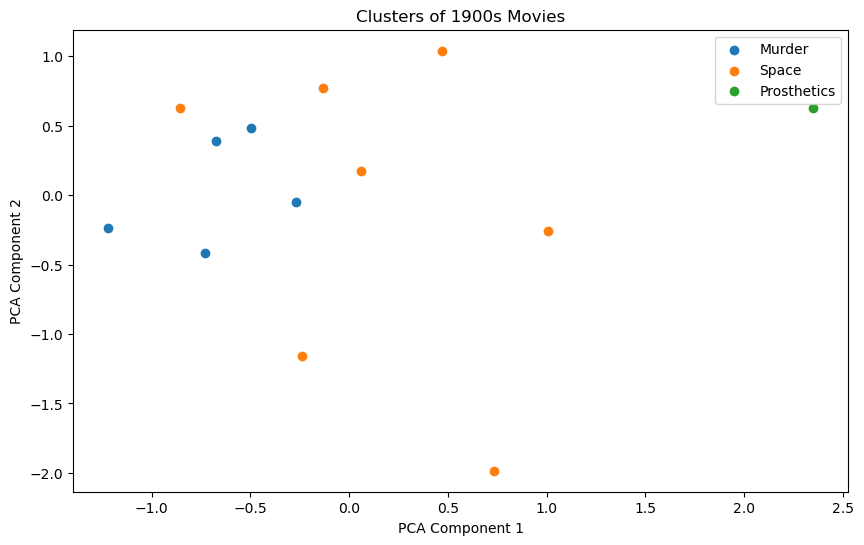

1it [00:00,  1.36it/s]

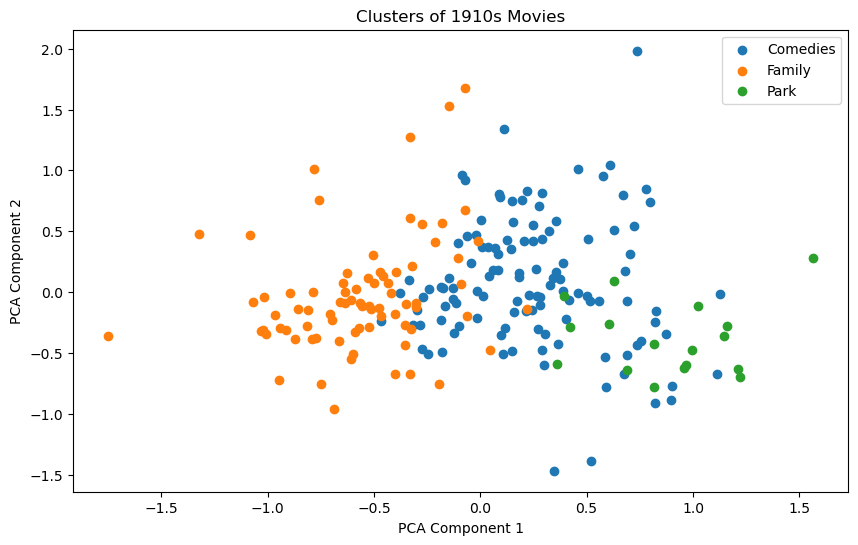

2it [00:01,  1.39it/s]

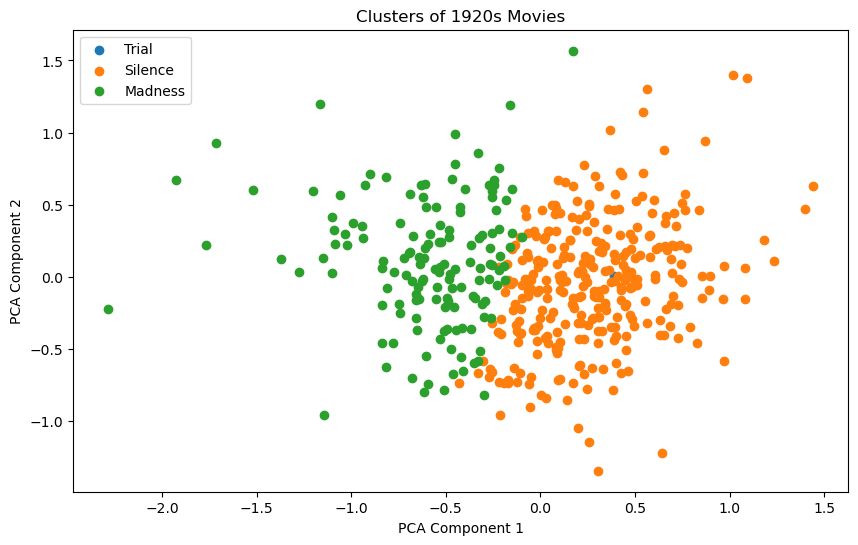

3it [00:02,  1.37it/s]

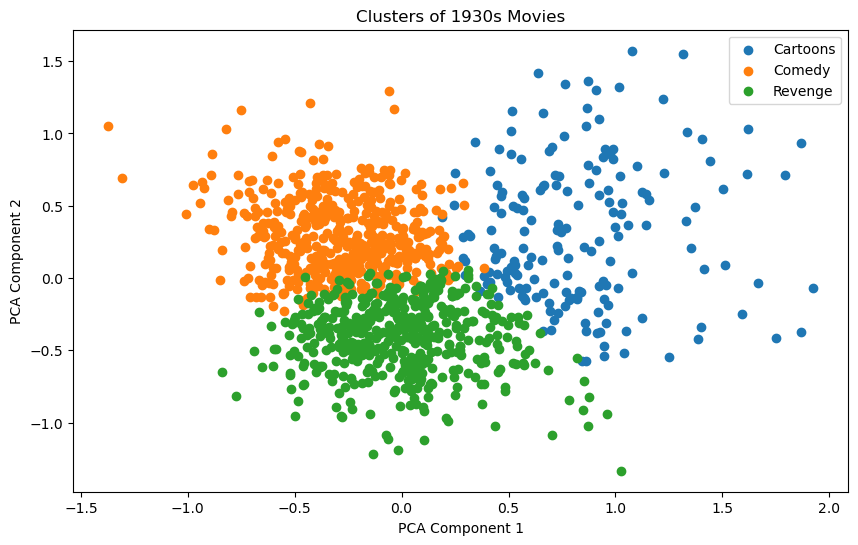

4it [00:02,  1.36it/s]

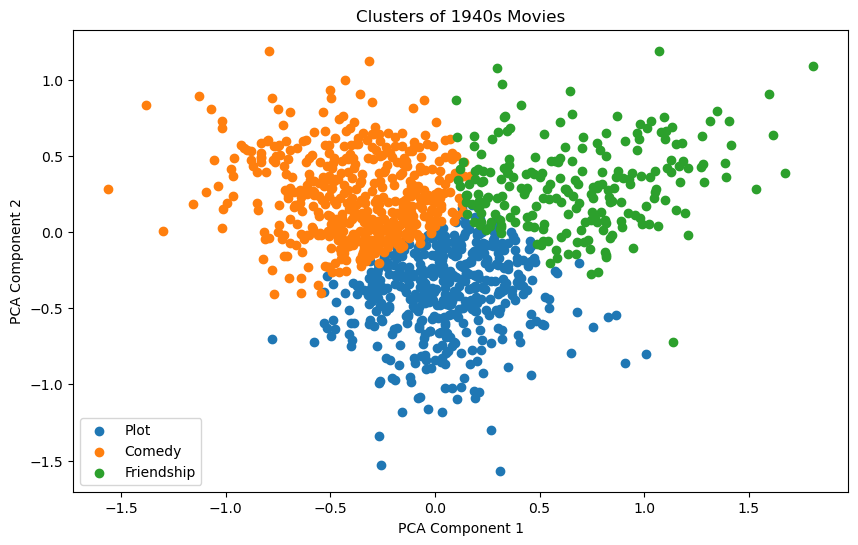

5it [00:03,  1.30it/s]

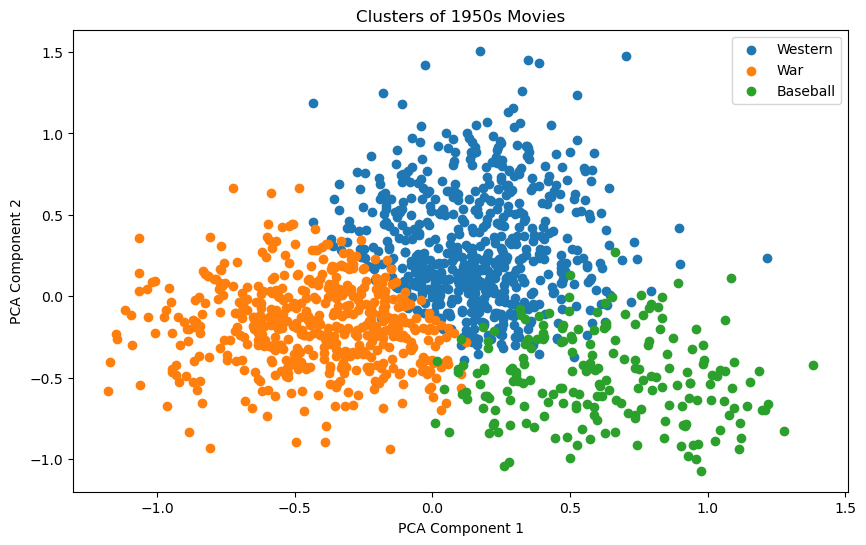

6it [00:04,  1.28it/s]

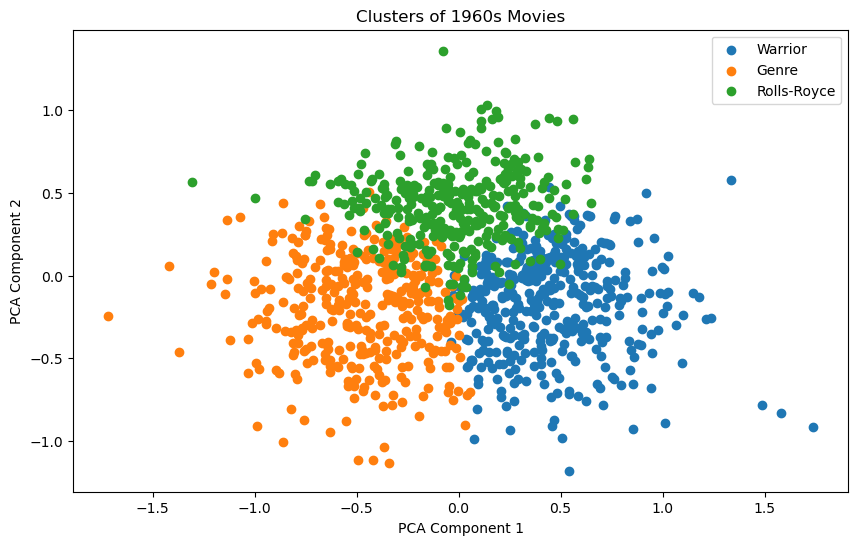

7it [00:05,  1.29it/s]

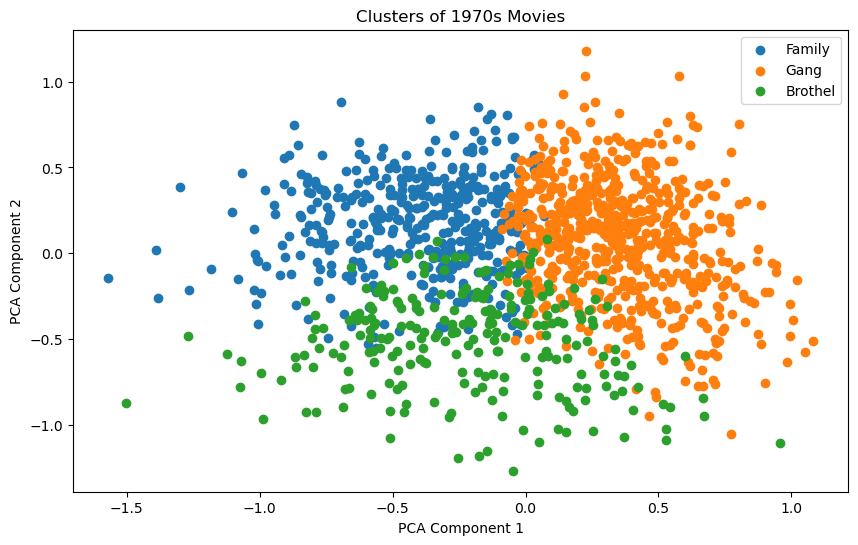

8it [00:06,  1.05it/s]

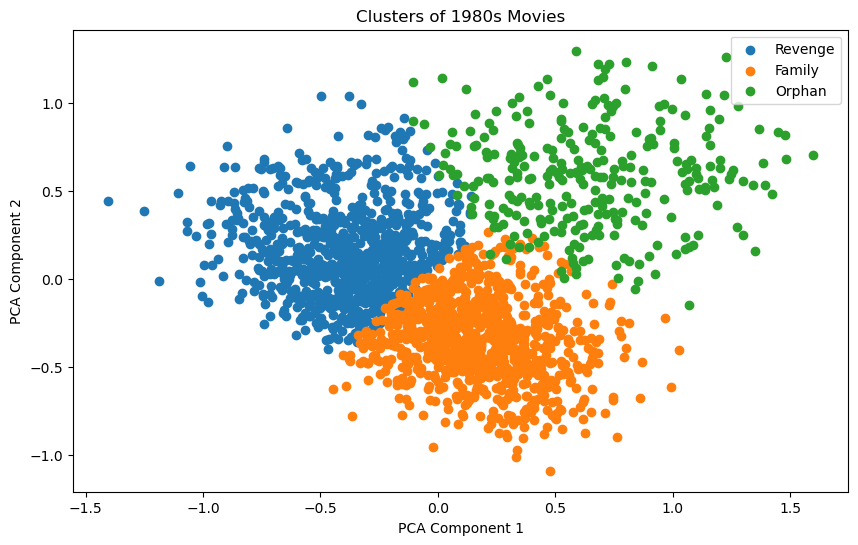

9it [00:07,  1.08it/s]

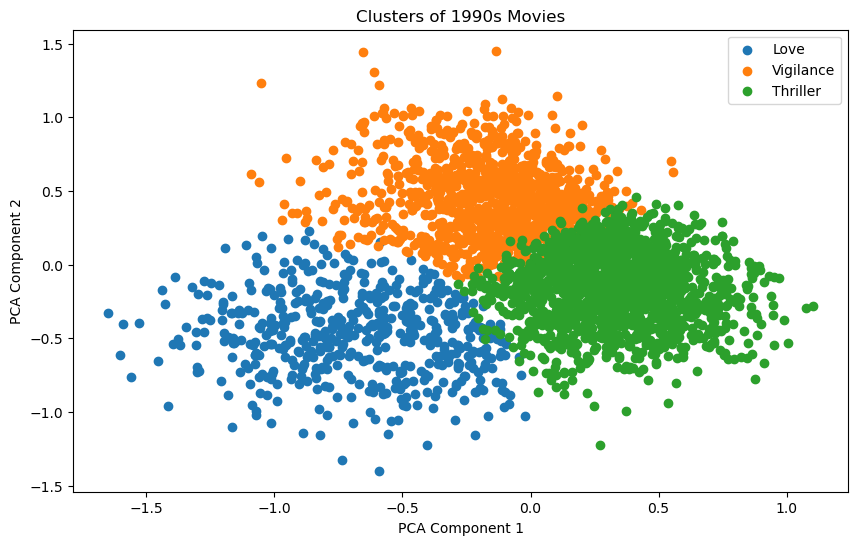

10it [00:08,  1.07it/s]

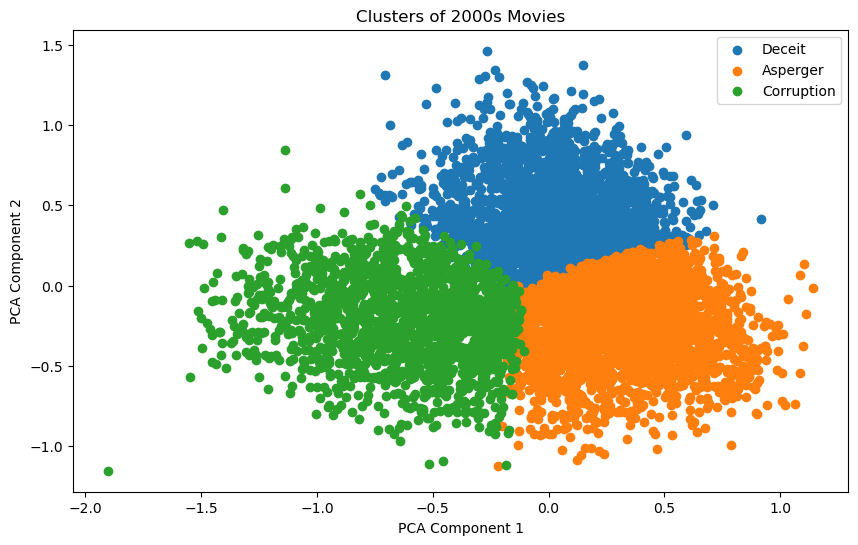

11it [00:09,  1.14it/s]


In [41]:
for i, decade in tqdm(enumerate(range(1900, 2010, 10))):
    names = [cluster_names[i+1][1], cluster_names[i+1][2], cluster_names[i+1][3]]
    plot_clusters_and_pca(embed_mov[i], str(decade), names, n_clusters=3)